# 02 EDA

## 1. Data

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
ROOT = Path.cwd().resolve().parent

Q8_PROCESSED_PATH = ROOT / "data" / "processed" / "yrbs_cycle3_q8_processed_only.csv"
HEALTH_RISK_PROCESSED_PATH = ROOT / "data" / "processed" / "yrbs_cycle3_health_risk_processed_only.csv"

FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# ------------------------------------------------------------
# Load processed-only data
# ------------------------------------------------------------
analysis = pd.read_csv(Q8_PROCESSED_PATH)
health_risk = pd.read_csv(HEALTH_RISK_PROCESSED_PATH)

print("Rows valid for health-risk extension:", len(health_risk))

Rows valid for health-risk extension: 12037


## 2. Visualization 3 (Additional EDA) : Health-risk Behavior Count

### 2.1 Health-risk Behavior Count Summary

In [2]:
health_risk_summary = (
    health_risk
    .groupby(["sad_binary", "sad_group"], as_index=False)
    .agg(
        n=("health_risk_behavior_count", "count"),
        mean_health_risk_count=("health_risk_behavior_count", "mean"),
    )
)

health_risk_summary = health_risk_summary.sort_values(
    "sad_binary",
    ascending=False
).reset_index(drop=True)

health_risk_summary.to_csv(
    TAB_DIR / "02_health_risk_behavior_count_summary_by_sad_group.csv",
    index=False
)

display(health_risk_summary)

,sad_binary,sad_group,n,mean_health_risk_count
0,1,Sad/Hopeless: Yes,3463,1.0907
1,0,Sad/Hopeless: No,8574,0.7182


#### **Interpretation**

This table compares the average number of health-risk behaviors between the **Sad/Hopeless: Yes** and **Sad/Hopeless: No** groups.

The **Sad/Hopeless: Yes** group had a higher mean health-risk behavior count than the **Sad/Hopeless: No** group. This means that students who felt sad or hopeless tended to report more health-risk behaviors overall.

### 2.2 Health-risk Behavior Count Distribution by Sad Group

In [3]:
risk_count_order = [0, 1, 2, 3]

risk_counts = (
    pd.crosstab(
        health_risk["sad_group"],
        health_risk["health_risk_behavior_count"]
    )
    .reindex(
        index=["Sad/Hopeless: No", "Sad/Hopeless: Yes"],
        columns=risk_count_order,
        fill_value=0
    )
    .fillna(0)
    .astype(int)
)

risk_props = (
    pd.crosstab(
        health_risk["sad_group"],
        health_risk["health_risk_behavior_count"],
        normalize="index"
    )
    .reindex(
        index=["Sad/Hopeless: No", "Sad/Hopeless: Yes"],
        columns=risk_count_order,
        fill_value=0
    )
    .fillna(0) * 100
)

risk_table = (
    risk_counts
    .reset_index()
    .melt(
        id_vars="sad_group",
        var_name="health_risk_behavior_count",
        value_name="count"
    )
)

risk_props_long = (
    risk_props
    .reset_index()
    .melt(
        id_vars="sad_group",
        var_name="health_risk_behavior_count",
        value_name="within_group_percent"
    )
)

risk_table = risk_table.merge(
    risk_props_long,
    on=["sad_group", "health_risk_behavior_count"]
)

risk_table.to_csv(
    TAB_DIR / "02_health_risk_behavior_count_distribution_by_sad_group.csv",
    index=False
)

display(risk_table)

,sad_group,health_risk_behavior_count,count,within_group_percent
0,Sad/Hopeless: No,0,4828,56.3098
1,Sad/Hopeless: Yes,0,1362,39.3301
2,Sad/Hopeless: No,1,2031,23.6879
3,Sad/Hopeless: Yes,1,966,27.8949
4,Sad/Hopeless: No,2,1018,11.8731
5,Sad/Hopeless: Yes,2,594,17.1528
6,Sad/Hopeless: No,3,697,8.1292
7,Sad/Hopeless: Yes,3,541,15.6223


### 2.3 Health-risk Behavior Count Stacked Bar Chart

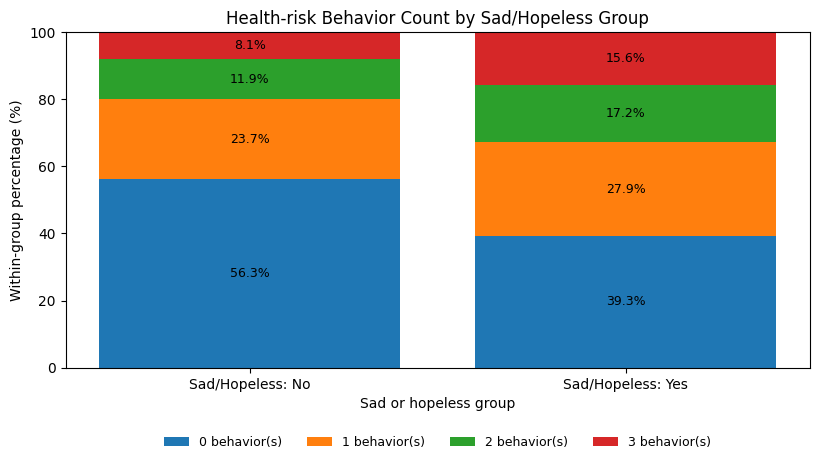

In [4]:
ct = risk_props.loc[
    ["Sad/Hopeless: No", "Sad/Hopeless: Yes"],
    [0, 1, 2, 3]
]

fig, ax = plt.subplots(figsize=(8.3, 4.8))
bottom = [0] * len(ct)

for col in [0, 1, 2, 3]:
    vals = ct[col].values
    ax.bar(
        ct.index,
        vals,
        bottom=bottom,
        label=f"{col} behavior(s)"
    )
    bottom = [b + v for b, v in zip(bottom, vals)]

ax.set_ylabel("Within-group percentage (%)")
ax.set_xlabel("Sad or hopeless group")
ax.set_title("Health-risk Behavior Count by Sad/Hopeless Group")
ax.set_ylim(0, 100)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.17),
    ncol=4,
    frameon=False,
    fontsize=9
)

for i, row in enumerate(ct.values):
    running = 0
    for val in row:
        if val >= 6:
            ax.text(
                i,
                running + val / 2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )
        running += val

plt.tight_layout()

fig.savefig(
    FIG_DIR / "02_health_risk_behavior_count_stacked_by_sad_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### **Interpretation**
Compared with the **Sad/Hopeless: No** group, the **Sad/Hopeless: Yes** group had a lower percentage of students with **0 health-risk behaviors** and a higher percentage of students with **2 or 3 health-risk behaviors**.

This suggests that students who felt sad or hopeless tended to report more health-risk behaviors overall. However, this is only an exploratory association and should not be interpreted as causation.